# DL_Demonstration — Checkpoint 7

Демонстрация использования финальной модели без обучения:
- загружаем зарегистрированную модель из MLflow (`PRD`),
- подготавливаем вход,
- выполняем инференс и интерпретируем результат.


In [1]:
import os
import json
import base64
from io import BytesIO
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import mlflow
from mlflow import MlflowClient

TRACKING_URI = os.environ.get("MLFLOW_TRACKING_URI", "http://127.0.0.1:5000")
mlflow.set_tracking_uri(TRACKING_URI)
client = MlflowClient()

prd_ref_path = Path("results/checkpoint7/prd_reference.json")
if prd_ref_path.exists():
    prd_ref = json.loads(prd_ref_path.read_text(encoding="utf-8"))
else:
    prd_ref = {}

MODEL_NAME = os.environ.get("MLFLOW_MODEL_NAME", prd_ref.get("model_name", "flux_attention_research"))
MODEL_ALIAS = os.environ.get("MLFLOW_MODEL_ALIAS", "PRD")

print({
    "tracking_uri": TRACKING_URI,
    "model_name": MODEL_NAME,
    "model_alias": MODEL_ALIAS,
    "prd_ref_exists": prd_ref_path.exists(),
})

if prd_ref:
    print("PRD reference:")
    print(json.dumps(prd_ref, ensure_ascii=False, indent=2))
else:
    print("[warn] results/checkpoint7/prd_reference.json is missing; will try Model Registry alias directly")



{'tracking_uri': 'http://127.0.0.1:5000', 'model_name': 'flux_attention_research', 'model_alias': 'PRD', 'prd_ref_exists': True}
PRD reference:
{
  "run_id": "2c879d81581444059e953fcc57e46183",
  "model_name": "flux_attention_research",
  "model_version": "2",
  "prd_uri": "models:/flux_attention_research@PRD",
  "artifact_model_uri": "runs:/2c879d81581444059e953fcc57e46183/prd_pyfunc_model",
  "tracking_uri": "http://127.0.0.1:5000",
  "experiment": "hse_research_flux_checkpoint7"
}


In [2]:
candidate_uris = []
if MODEL_NAME:
    candidate_uris.append(f"models:/{MODEL_NAME}@{MODEL_ALIAS}")
if prd_ref.get("prd_uri"):
    candidate_uris.append(prd_ref["prd_uri"])
if prd_ref.get("artifact_model_uri"):
    candidate_uris.append(prd_ref["artifact_model_uri"])

loaded_model = None
used_uri = None
for uri in candidate_uris:
    try:
        loaded_model = mlflow.pyfunc.load_model(uri)
        used_uri = uri
        break
    except Exception as e:
        print("[warn] cannot load", uri, "->", e)

if loaded_model is None:
    raise RuntimeError("Failed to load PRD model from all candidate URIs")

print("Loaded model URI:", used_uri)
if "@PRD" not in str(used_uri):
    print("[info] Loaded by fallback URI; PRD alias may be unavailable in this tracking server session")



Loaded model URI: models:/flux_attention_research@PRD


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

You set `add_prefix_space`. The tokenizer needs to be converted from the slow tokenizers


  0%|          | 0/4 [00:00<?, ?it/s]

,prompt,seed,image_base64
0,a watercolor portrait of a fox in autumn park,73,iVBORw0KGgoAAAANSUhEUgAAAwAAAAMACAIAAAAc45fZAA...


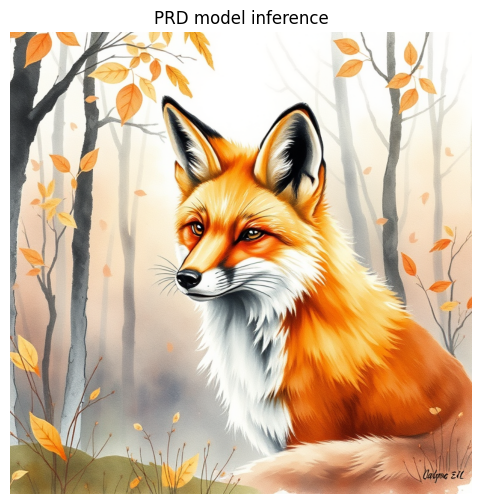

In [3]:
# Тестовый предикт
demo_input = pd.DataFrame([
    {"prompt": "a watercolor portrait of a fox in autumn park", "seed": 73},
])

pred_df = loaded_model.predict(demo_input)
display(pred_df.head())

if "image_base64" not in pred_df.columns:
    raise RuntimeError("Expected image_base64 in prediction output")

b = base64.b64decode(pred_df.iloc[0]["image_base64"])
img = Image.open(BytesIO(b)).convert("RGB")

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis("off")
plt.title("PRD model inference")
plt.show()

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

,prompt,seed,image_path,loaded_model_uri
0,a watercolor portrait of a fox in autumn park,73,results/checkpoint7/demo_images/prd_demo_0.png,models:/flux_attention_research@PRD
1,"a small stone house near a river, watercolor p...",74,results/checkpoint7/demo_images/prd_demo_1.png,models:/flux_attention_research@PRD
2,"a vintage red car near a quiet cafe, soft past...",75,results/checkpoint7/demo_images/prd_demo_2.png,models:/flux_attention_research@PRD


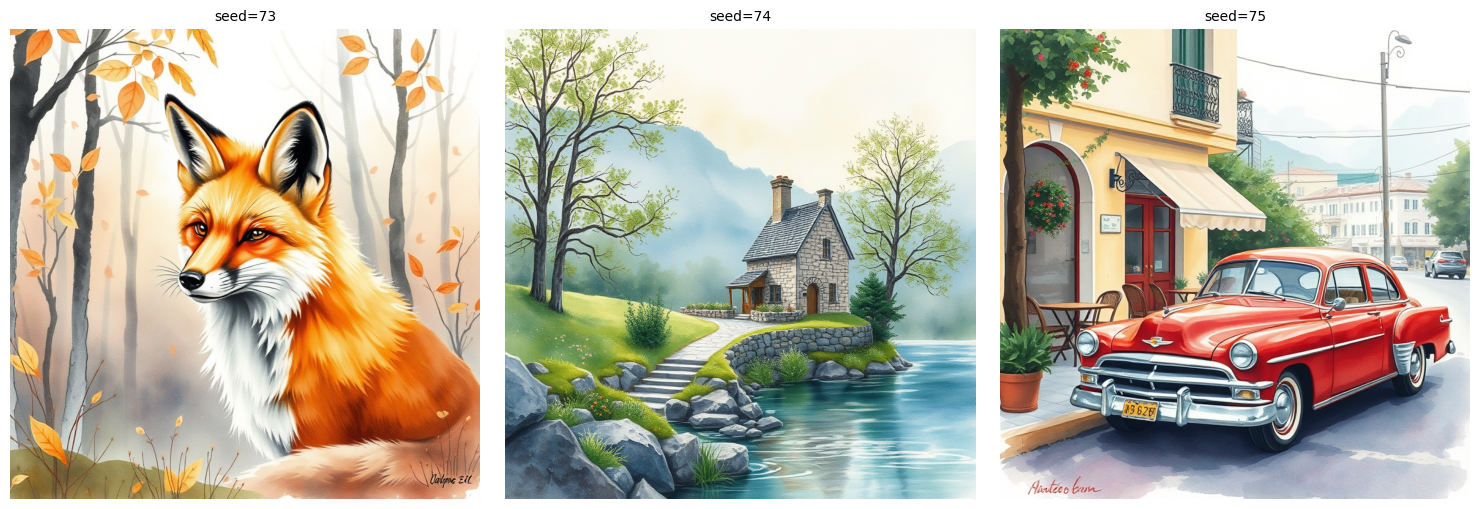

Saved demo artifacts:
- results/checkpoint7/demo_predictions.csv
- results/checkpoint7/demo_images/prd_demo_0.png
- results/checkpoint7/demo_images/prd_demo_1.png
- results/checkpoint7/demo_images/prd_demo_2.png


In [4]:
# Несколько демонстрационных примеров для отчета
demo_examples = pd.DataFrame([
    {"prompt": "a watercolor portrait of a fox in autumn park", "seed": 73},
    {"prompt": "a small stone house near a river, watercolor paper texture", "seed": 74},
    {"prompt": "a vintage red car near a quiet cafe, soft pastel watercolor", "seed": 75},
])

demo_pred_df = loaded_model.predict(demo_examples)

demo_dir = Path("results/checkpoint7/demo_images")
demo_dir.mkdir(parents=True, exist_ok=True)

decoded_images = []
rows = []
for i, row in demo_pred_df.iterrows():
    img_bytes = base64.b64decode(row["image_base64"])
    img = Image.open(BytesIO(img_bytes)).convert("RGB")
    out_path = demo_dir / f"prd_demo_{i}.png"
    img.save(out_path)
    decoded_images.append(img)
    rows.append({
        "prompt": row["prompt"],
        "seed": int(row["seed"]),
        "image_path": str(out_path),
        "loaded_model_uri": used_uri,
    })

demo_summary = pd.DataFrame(rows)
demo_summary_path = Path("results/checkpoint7/demo_predictions.csv")
demo_summary.to_csv(demo_summary_path, index=False)
display(demo_summary)

fig, axes = plt.subplots(1, len(decoded_images), figsize=(5 * len(decoded_images), 5))
if len(decoded_images) == 1:
    axes = [axes]

for ax, img, row in zip(axes, decoded_images, rows):
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(f"seed={row['seed']}", fontsize=10)

plt.tight_layout()
plt.show()

print("Saved demo artifacts:")
print("-", demo_summary_path)
for r in rows:
    print("-", r["image_path"])


## Интерпретация результата

Демонстрационный блок показывает не обучение, а именно использование финальной версии: модель загружается из MLflow Model Registry по alias `PRD` (`models:/flux_attention_research@PRD`) или по сохраненному fallback URI из `prd_reference.json`.

По результатам инференса важно зафиксировать три вещи:

1. Версия модели воспроизводимо определяется через MLflow, а не через ручной выбор весов или локальный путь.
2. На вход подаются только `prompt` и `seed`; обучение и подбор параметров в демонстрационном ноутбуке не выполняются.
3. Сгенерированные изображения и таблица промптов сохраняются как артефакты в `results/checkpoint7/demo_images/` и `results/checkpoint7/demo_predictions.csv`, поэтому результат можно приложить к отчету.

Так демонстрация закрывает второй логический блок чекпойнта: финальная модель уже получена и зарегистрирована в `DL_Experiments.ipynb`, а здесь показано ее практическое использование.
